In [2]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import precision_score, recall_score, average_precision_score,precision_recall_curve
import joblib
from sklearn.model_selection import RandomizedSearchCV

In [3]:
df = pd.read_csv("../data/creditcard.csv")
df["LogAmount"] = np.log1p(df["Amount"])

X = df.drop(["Class", "Amount"], axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
#Optimized parameters based on RandomizedSearchCV
model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

""" param_grid = {
    "max_depth": [3,4,5,6,7],
    "learning_rate": [0.01,0.03,0.05,0.1],
    "n_estimators": [200,400,600],
    "subsample": [0.7,0.8,0.9,1],
    "colsample_bytree": [0.7,0.8,0.9,1]
}

search = RandomizedSearchCV(
    model,
    param_grid,
    n_iter=20,
    scoring="average_precision",
    cv=3,
    n_jobs=-1
) """

' param_grid = {\n    "max_depth": [3,4,5,6,7],\n    "learning_rate": [0.01,0.03,0.05,0.1],\n    "n_estimators": [200,400,600],\n    "subsample": [0.7,0.8,0.9,1],\n    "colsample_bytree": [0.7,0.8,0.9,1]\n}\n\nsearch = RandomizedSearchCV(\n    model,\n    param_grid,\n    n_iter=20,\n    scoring="average_precision",\n    cv=3,\n    n_jobs=-1\n) '

In [63]:
print(scale_pos_weight)

577.2868020304569


In [3]:
#search.fit(X_train, y_train)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=-1, num_parallel_tree=None, ...)

In [4]:
#model = joblib.load("../models/xgboost_optimized.pkl")

In [ ]:
y_pred = model.predict(X_test)
y_scores = model.predict_proba(X_test)[:,1]

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auprc = average_precision_score(y_test, y_scores)

print("Precision:", precision)
print("Recall:", recall)
print("AUPRC:", auprc)

[0 0 0 ... 0 0 0]
[2.6352220e-06 3.4214540e-06 3.0649215e-05 ... 2.0838881e-06 1.9124869e-05
 7.6299584e-06]
Precision: 0.8541666666666666
Recall: 0.8367346938775511
AUPRC: 0.8834729404388332


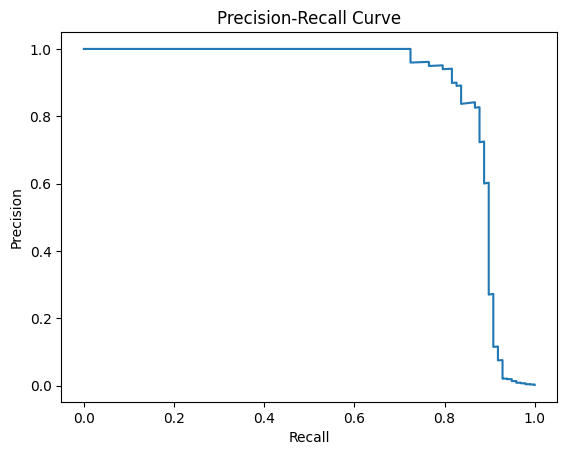

In [6]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_scores)

plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

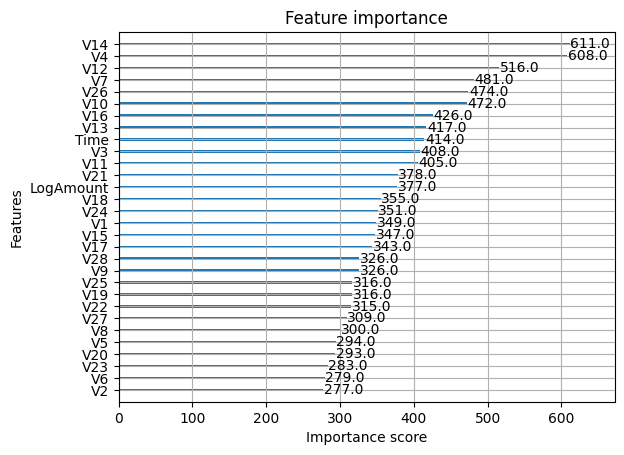

In [22]:
xgb.plot_importance(model)

In [8]:
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

f1 = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[f1.argmax()]

print(best_threshold)

y_pred_opt = (y_scores >= best_threshold).astype(int)

precision = precision_score(y_test, y_pred_opt)
recall = recall_score(y_test, y_pred_opt)

print("Precision:", precision)
print("Recall:", recall)

0.9270787
Precision: 0.9411764705882353
Recall: 0.8163265306122449


In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model,
    X,
    y,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

print("AUPRC per fold:", scores)
print("Mean AUPRC:", scores.mean())

AUPRC per fold: [0.85291506 0.9000497  0.87426562 0.86007693 0.83420299]
Mean AUPRC: 0.8643020595318763


c:\Users\youss\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


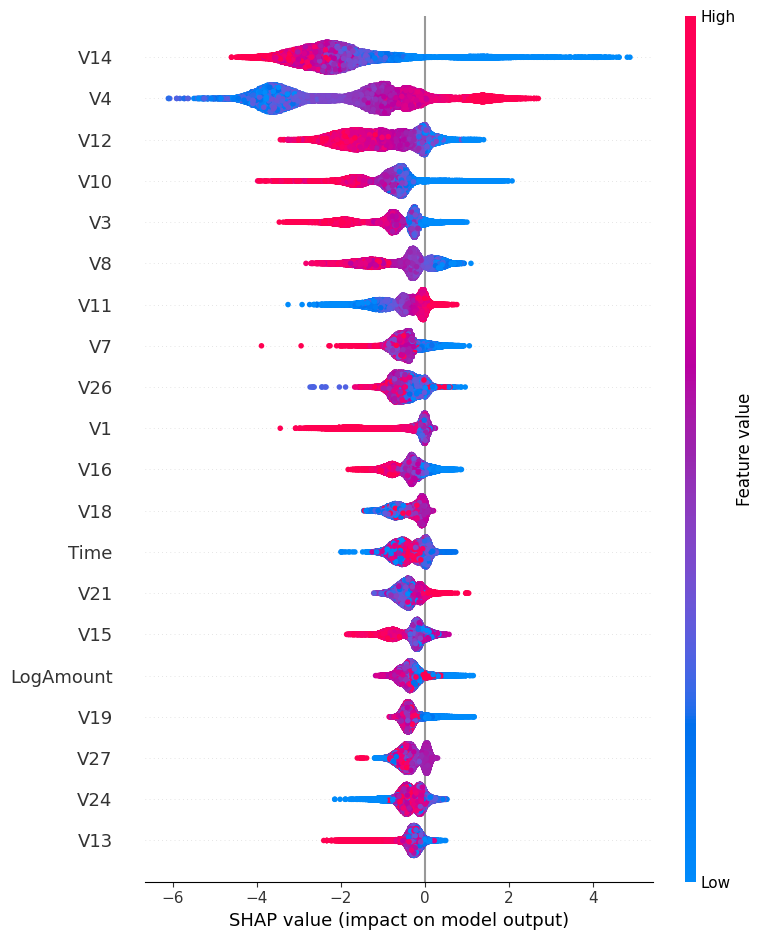

In [10]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [48]:
fn_idx = (y_test == 1) & (y_pred == 0)
tp_idx = (y_test == 1) & (y_pred == 1)
false_negatives = X_test[fn_idx]
true_positives = X_test[tp_idx]
print(false_negatives.shape[0])
print(true_positives.shape[0])

16
82


In [ ]:
false_negatives[["V14", "V4", "V12", "V7", "V26", "V10"]].describe()
#true_positives.describe()

,V14,V4,V12,V7,V26,V10
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,-1.804281,2.031020,-2.052151,-0.553816,-0.081982,-0.735095
std,2.804716,2.204200,3.206869,3.695403,0.369647,2.741311
min,-8.640459,-1.255593,-11.635630,-13.897827,-0.734449,-9.668789
25%,-3.328068,0.282946,-2.796806,-0.181370,-0.276242,-0.999251
50%,-0.794930,2.140880,-0.827024,0.192342,-0.114127,-0.053951
75%,-0.234227,3.264994,-0.232429,0.649658,0.199904,1.025957
max,1.571080,6.185969,0.922184,2.114531,0.699175,1.783739


In [42]:
true_positives[["V14", "V4", "V12", "V7", "V26", "V10"]].describe()

,V14,V4,V12,V7,V26,V10
count,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000
mean,-8.252082,4.787195,-7.259176,-6.685737,0.096081,-6.591483
std,3.649507,2.736156,4.099786,6.806245,0.509287,4.357481
min,-18.822087,-0.572676,-18.553697,-31.197329,-1.149923,-22.187089
25%,-10.585637,2.803155,-9.241343,-10.554957,-0.279454,-8.685500
50%,-7.536370,4.335516,-6.750911,-3.941816,0.185400,-5.169071
75%,-5.254563,6.341929,-4.135592,-2.096975,0.481498,-3.467619
max,-0.673818,11.927512,-0.468572,5.431271,1.165784,1.015113


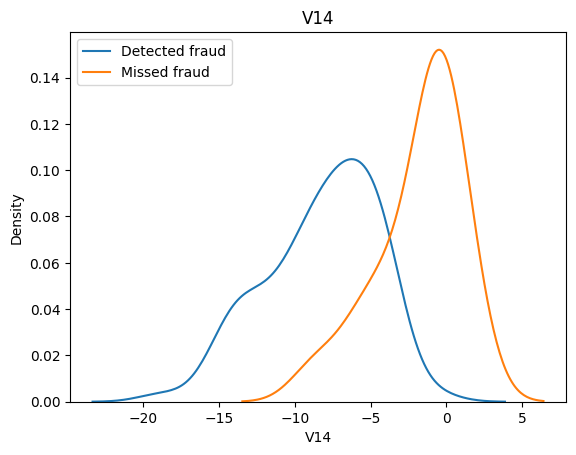

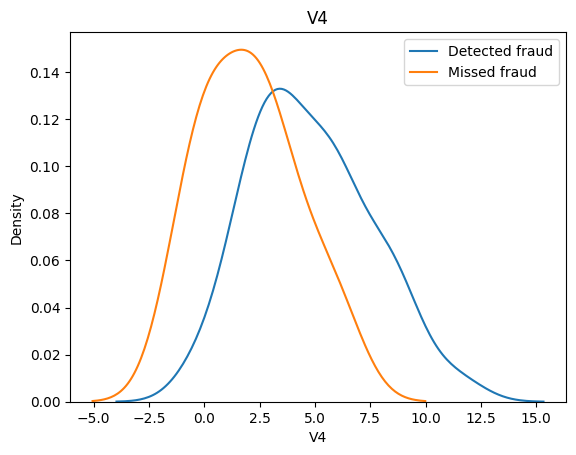

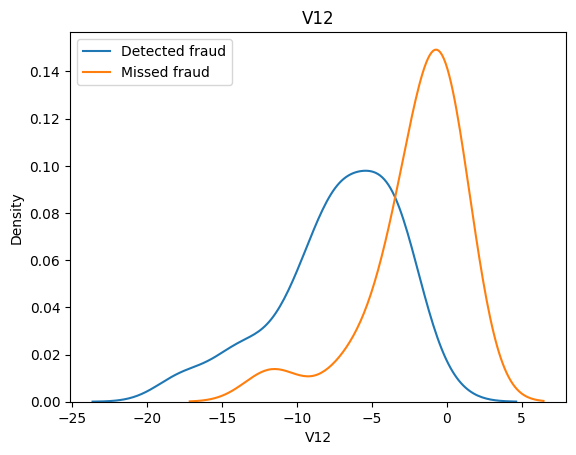

In [43]:
features = ["V14","V4","V12"]

for f in features:
    sns.kdeplot(true_positives[f], label="Detected fraud")
    sns.kdeplot(false_negatives[f], label="Missed fraud")
    plt.title(f)
    plt.legend()
    plt.show()

The analysis of false negatives reveals that their distributions for the most important PCA components (V14, V4, V12) are centered around zero, while correctly detected frauds tend to have values further away from zero. Since these variables result from a PCA transformation, values close to zero correspond to average transaction behavior. This suggests that missed frauds exhibit patterns closer to legitimate transactions, making them inherently more difficult for the model to distinguish.

In [59]:
important_features = ["V14","V4","V12"]

fn_distance = false_negatives[important_features].abs().mean()
tp_distance = true_positives[important_features].abs().mean()

print("False negatives distance:", fn_distance)
print("True positives distance:", tp_distance)

False negatives distance: V14    2.231543
V4     2.320539
V12    2.262634
dtype: float64
True positives distance: V14    8.252082
V4     4.804859
V12    7.259176
dtype: float64


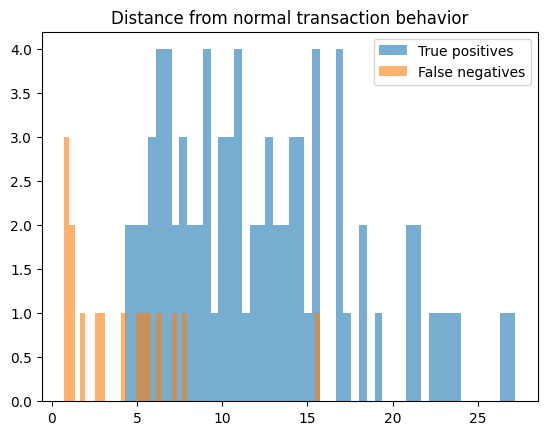

In [ ]:
fn_norm = np.linalg.norm(false_negatives[["V14","V4","V12"]], axis=1)
tp_norm = np.linalg.norm(true_positives[["V14","V4","V12"]], axis=1)

plt.hist(tp_norm, bins=50, alpha=0.6, label="True positives")
plt.hist(fn_norm, bins=50, alpha=0.6, label="False negatives")

plt.legend()
plt.title("Distance from normal transaction behavior")
plt.show()

In [61]:
results = pd.DataFrame({
    "y_true": y_test,
    "proba": y_scores
})

# tri par probabilité décroissante
results = results.sort_values("proba", ascending=False)

total_fraud = results["y_true"].sum()

def top_k_capture_rate(df, k_percent):

    k = int(len(df) * k_percent)

    top_k = df.head(k)

    fraud_in_top_k = top_k["y_true"].sum()

    return fraud_in_top_k / total_fraud

for k in [0.001, 0.005, 0.01, 0.02, 0.05]:

    rate = top_k_capture_rate(results, k)

    print(f"Top {k*100:.1f}% → {rate:.3f} fraud capture")

Top 0.1% → 0.571 fraud capture
Top 0.5% → 0.898 fraud capture
Top 1.0% → 0.908 fraud capture
Top 2.0% → 0.918 fraud capture
Top 5.0% → 0.929 fraud capture


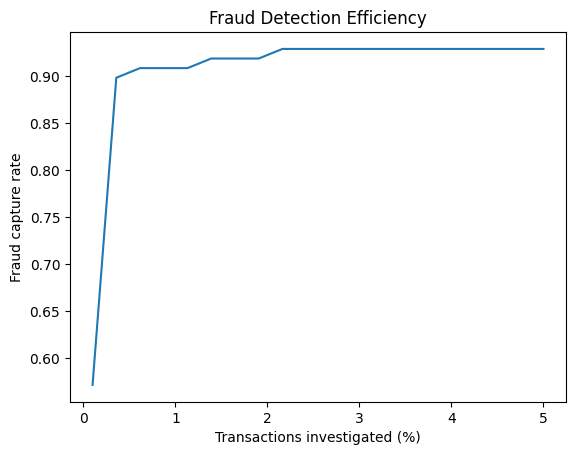

In [62]:
ks = np.linspace(0.001, 0.05, 20)

rates = [top_k_capture_rate(results, k) for k in ks]

import matplotlib.pyplot as plt

plt.plot(ks*100, rates)

plt.xlabel("Transactions investigated (%)")
plt.ylabel("Fraud capture rate")
plt.title("Fraud Detection Efficiency")

plt.show()

The Top-K fraud capture analysis highlights the strong ranking ability of the model. By inspecting only the 0.5% most suspicious transactions, nearly 90% of fraudulent transactions are detected. Increasing the inspection budget to 1% of transactions only marginally improves detection, capturing about 91% of frauds. This indicates that the model is highly effective at prioritizing risky transactions, concentrating the vast majority of fraud cases within a very small fraction of the dataset. Such performance is particularly valuable in operational fraud detection systems where investigation resources are limited.

In [5]:
from xgboost import XGBClassifier
import json

# Tes meilleurs params — récupère les depuis le best_run MLflow
best_params = {
    "n_estimators": 300,      # ← tes valeurs
    "max_depth": 6,
    "learning_rate": 0.1,
    "scale_pos_weight": 300,
    "subsample": 0.8,
}
best_threshold = 0.9584       # ← ton threshold

# Réentraîner (rapide, ~30 sec)
final_model = XGBClassifier(**best_params, eval_metric='aucpr', random_state=42)
final_model.fit(X_train, y_train)

# Sauvegarder en format natif
final_model.save_model("../models/xgboost_fraud_best.json")

with open("../models/threshold_best.json", "w") as f:
    json.dump({"threshold": float(best_threshold)}, f)

print("✅ Modèles sauvegardés en format JSON")
print(f"   threshold = {best_threshold}")

✅ Modèles sauvegardés en format JSON
   threshold = 0.9584
